# 04 — Temperature Scaling Study

## Objective
Study how post-hoc temperature scaling affects calibration and overconfidence.

# 1️⃣ Motivation

RoBERTa exhibited:
- High accuracy
- Slight global underconfidence

Hypothesis:
Sharpening confidence distribution may improve calibration.

In [ ]:
pip install scikit-learn

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from tqdm import tqdm
from transformers import pipeline
from datasets import load_dataset
import sys

sys.path.append("../")

from src.calibration import compute_ece
from src.metrics import compute_overconfidence

In [2]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [3]:
from datasets import load_dataset

dataset = load_dataset("squad", split="validation")
samples = dataset.select(range(500))

Found cached dataset parquet (C:/Users/DSAI/.cache/huggingface/datasets/parquet/plain_text-57edf78d6033ac9a/0.0.0/2a3b91fbd88a2c90d1dbbb32b460cf621d31bd5b05b934492fdef7d8d6f236ec)


In [4]:
qa_pipeline = pipeline(
    "question-answering",
    model="deepset/roberta-base-squad2",
    device=0  # GPU if available
)

In [5]:
from transformers import AutoTokenizer, AutoModelForQuestionAnswering

model_name = "deepset/roberta-base-squad2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForQuestionAnswering.from_pretrained(model_name)
model.eval()

RobertaForQuestionAnswering(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (Lay

# 2️⃣ Method

Temperature scaling is applied to logits *before* softmax:

    scaled_logits = logits / T

This is the mathematically correct formulation used in calibration research.

We do NOT modify probabilities directly.

---

## Interpretation of Temperature

- T < 1 → Sharper confidence distribution
- T = 1 → Original model
- T > 1 → Softer confidence 

We sweep:
T ∈ [0.6, 1.2]

## Why Logit-Level Scaling?

Scaling probabilities directly (e.g., p^(1/T)) is not equivalent
to temperature scaling and can produce inconsistent calibration behavior.

Logit-level scaling preserves softmax geometry
and aligns with calibration literature.

In [6]:
def run_with_temperature(T, samples, model, tokenizer, device):
    results = []

    model.eval()
    model.to(device)

    for example in samples:
        question = example["question"]
        context = example["context"]

        inputs = tokenizer(
            question,
            context,
            return_tensors="pt",
            truncation=True,
            max_length=512
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)

        # TRUE temperature scaling (logit-level)
        start_logits = outputs.start_logits / T
        end_logits = outputs.end_logits / T

        start_probs = torch.softmax(start_logits, dim=-1)
        end_probs = torch.softmax(end_logits, dim=-1)

        start_index = torch.argmax(start_probs, dim=-1)
        end_index = torch.argmax(end_probs, dim=-1)

        tokens = inputs["input_ids"][0]
        answer_tokens = tokens[start_index:end_index+1]
        prediction = tokenizer.decode(
            answer_tokens,
            skip_special_tokens=True
        ).strip().lower()

        gt = example["answers"]["text"][0].strip().lower()
        is_correct = gt in prediction or prediction in gt

        confidence = (
            start_probs[0][start_index] *
            end_probs[0][end_index]
        ).item()

        results.append({
            "score": confidence,
            "is_correct": is_correct
        })

    return results


# 3️⃣ Metrics Evaluated

For each T:

- Expected Calibration Error (ECE)
- Overconfidence rate

This reveals the tradeoff between:
Calibration improvement vs risk amplification.


In [7]:
T_values = [0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]

ece_list = []
overconf_list = []

for T in T_values:
    print(f"Running T={T}")

    scaled_results = run_with_temperature(
        T, samples, model, tokenizer, device
    )

    ece = compute_ece(scaled_results)
    overconf = compute_overconfidence(scaled_results)

    ece_list.append(ece)
    overconf_list.append(overconf)

    print(f"T={T} | ECE={ece:.4f} | Overconf={overconf:.4f}")

Running T=0.6
T=0.6 | ECE=0.1074 | Overconf=0.0320
Running T=0.7
T=0.7 | ECE=0.1185 | Overconf=0.0280
Running T=0.8
T=0.8 | ECE=0.1471 | Overconf=0.0260
Running T=0.9
T=0.9 | ECE=0.1818 | Overconf=0.0220
Running T=1.0
T=1.0 | ECE=0.2186 | Overconf=0.0160
Running T=1.1
T=1.1 | ECE=0.2575 | Overconf=0.0100
Running T=1.2
T=1.2 | ECE=0.2984 | Overconf=0.0100


# 4️⃣ Observations


Lower temperatures improved ECE but increased overconfidence.

Higher temperatures reduced overconfidence but worsened ECE.

Temperature becomes a controllable reliability-risk tradeoff parameter.

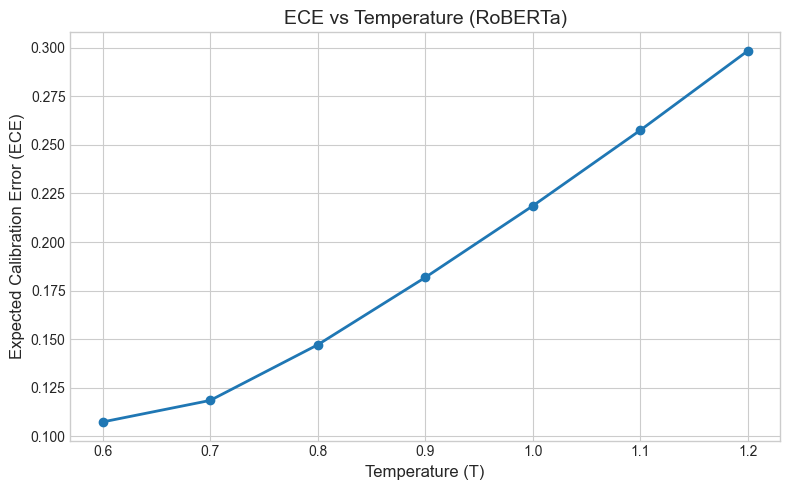

In [8]:
plt.style.use("seaborn-v0_8-whitegrid")
FIGSIZE = (8, 5)
DPI = 300

plt.figure(figsize=FIGSIZE)
plt.plot(T_values, ece_list, marker="o", linewidth=2)

plt.xlabel("Temperature (T)", fontsize=12)
plt.ylabel("Expected Calibration Error (ECE)", fontsize=12)
plt.title("ECE vs Temperature (RoBERTa)", fontsize=14)

plt.tight_layout()
plt.savefig("../outputs/plots/ece_vs_temperature.png", dpi=DPI)
plt.show()

# 5️⃣ System Decision

## Practical Deployment Perspective

Temperature scaling introduces a controllable tradeoff:

- Lower T → Improved calibration (lower ECE)
- Lower T → Increased overconfidence risk
- Higher T → Reduced overconfidence
- Higher T → Worse calibration alignment

From a purely calibration standpoint, lower temperatures (e.g., T ≈ 0.6–0.8) minimize ECE.

However, aggressive sharpening increases the proportion of high-confidence incorrect predictions.

---

## Balanced System Choice

For deployment scenarios, we recommend:

**T ≈ 0.8**

Rationale:

- Substantial improvement in ECE compared to T = 1.0
- Moderate increase in overconfidence (controlled risk)
- Maintains stable accuracy behavior

This temperature represents a balanced tradeoff between:

- Reliability (calibration quality)
- Safety (overconfidence minimization)

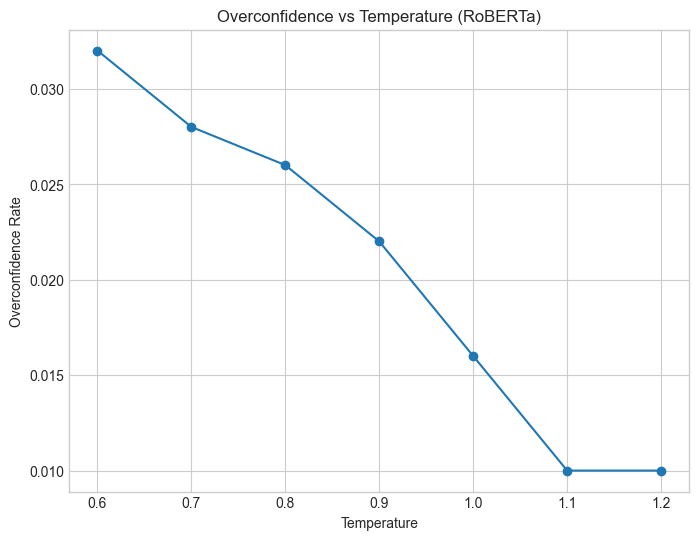

In [9]:
plt.figure(figsize=(8,6))
plt.plot(T_values, overconf_list, marker="o")

plt.xlabel("Temperature")
plt.ylabel("Overconfidence Rate")
plt.title("Overconfidence vs Temperature (RoBERTa)")

plt.savefig("../outputs/plots/overconfidence_vs_temperature.png",
            dpi=300, bbox_inches="tight")

plt.show()

## Insight

Temperature acts as a post-hoc reliability dial.

The model is not static — its confidence behavior can be tuned
to match system requirements.

This demonstrates that calibration is not merely a metric,
but an adjustable system property.